In [ ]:
import pandas as pd
from src.data import DATA_DIR_INTERIM, DATA_DIR_PROCESSED

from topic_gen.models import Topics
from topic_gen.evaluate import CosineSimilarity, BertScore, JaccardIndex, TopicEvaluator, RelativeLength
from src.data import load_topics_from_path

In [2]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "topics-robust"
predictions, names, metadata = load_topics_from_path(BASE_DIR)

[topic_gen] [WARNING] (data.py:98) Metadata not found for result 2025-12-04_09:58:57, skipping...
[topic_gen] [WARNING] (data.py:98) Metadata not found for result 2025-12-01_07:07:25, skipping...


In [3]:
reference = Topics.load_ird_topics("disks45/nocr/trec-robust-2004")

In [ ]:
# results = TopicEvaluator.experiment(
#     predictions=predictions,
#     reference=reference,
#     measures=[CosineSimilarity(), BertScore(), JaccardIndex(), RelativeLength()],
#     names=names)
# df = pd.DataFrame(results)
# df.to_csv(DATA_DIR_PROCESSED / "topic_evaluation_robust.csv.gz", index=False, compression="gzip")

100%|██████████| 153/153 [28:38<00:00, 11.23s/it]


In [9]:
df = pd.read_csv(DATA_DIR_PROCESSED / "topic_evaluation_robust.csv.gz")

In [10]:
missing = (df[["name", "missing"]].drop_duplicates().set_index("name").to_dict()["missing"])

df = df.pivot(index=["name"], columns=["measure", "field"],
              values="value").reset_index()
df["missing"] = df["name"].map(missing)

metadata_prep = metadata.copy()
metadata_prep.columns = pd.MultiIndex.from_product(
    [metadata_prep.columns, ['']])
df = df.merge(metadata_prep, left_on=[("name", "")], right_on=[('date', '')])

## Table

In [12]:
df[[('model', ''), ('prompt', ''), ('nqueries', ''), ('ndocspos', ''), ('ndocsneg', ''),
    ("CosineSimilarity", "title"), ("BertScore",
                                    "title"), ("JaccardIndex", "title"), ("RelativeLength", "title"),
    ("CosineSimilarity", "description"), ("BertScore", "description"), ("JaccardIndex",
                                                                        "description"), ("RelativeLength", "description"),
    ("CosineSimilarity", "narrative"), ("BertScore", "narrative"), ("JaccardIndex", "narrative"), ("RelativeLength", "narrative")]]

,model,prompt,nqueries,ndocspos,ndocsneg,CosineSimilarity,BertScore,JaccardIndex,RelativeLength,CosineSimilarity,BertScore,JaccardIndex,RelativeLength,CosineSimilarity,BertScore,JaccardIndex,RelativeLength
,,,,,,title,title,title,title,description,description,description,description,narrative,narrative,narrative,narrative
0,qwen3-30B-no-think,topic-query,1,0,0,0.811510,0.732312,0.638784,1.057050,0.774290,0.703996,0.732947,1.137545,0.663549,0.547062,0.713933,2.109464
1,qwen3-30B-no-think,topic-query,3,0,0,0.790550,0.720679,0.623322,1.135053,0.791652,0.711159,0.733528,1.282350,0.673041,0.550086,0.713794,2.260196
2,qwen3-30B-no-think,topic-query,5,0,0,0.780949,0.712319,0.614243,1.163657,0.791098,0.703346,0.727652,1.409695,0.680211,0.552026,0.712601,2.334805
3,qwen3-30B-no-think,topic-query,7,0,0,0.780041,0.708803,0.608687,1.199719,0.788003,0.700654,0.722116,1.507885,0.675895,0.550416,0.708066,2.407650
4,qwen3-30B-no-think,topic-docs-pos,0,1,0,0.348263,0.559055,0.433333,1.248060,0.393217,0.595408,0.640016,1.638286,0.408130,0.507336,0.639964,2.913458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,llama3-1-70B_instruct_q8_0_ollama,topic-contrastive,0,5,5,0.515521,0.611805,0.503673,1.545141,0.521611,0.632510,0.670863,1.257977,0.491801,0.539912,0.720515,1.770414
149,llama3-1-70B_instruct_q8_0_ollama,topic-query-contrastive,1,1,1,0.864295,0.781963,0.686764,1.089258,0.751704,0.707541,0.721459,0.912777,0.667959,0.569993,0.732797,1.697495
150,llama3-1-70B_instruct_q8_0_ollama,topic-query-contrastive,2,2,2,0.860389,0.767669,0.679392,1.224119,0.779130,0.714554,0.732555,0.988452,0.673687,0.569266,0.734348,1.718976


### Plot

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv(DATA_DIR_PROCESSED / "topic_evaluation_robust.csv.gz")

In [19]:
df = df.merge(metadata, left_on=["name"], right_on=["date"])[
    ["measure", "value", "field", "model", "prompt", "nqueries", "ndocspos", "ndocsneg"]]

In [67]:
df[(df["nqueries"] == df["ndocspos"]) & df["nqueries"] == df["ndocsneg"]]

,measure,value,field,model,prompt,nqueries,ndocspos,ndocsneg
12,CosineSimilarity,0.749375,title,qwen3-14B-no-think,topic-query-contrastive,1,1,1
13,BertScore,0.713201,title,qwen3-14B-no-think,topic-query-contrastive,1,1,1
14,JaccardIndex,0.594087,title,qwen3-14B-no-think,topic-query-contrastive,1,1,1
15,RelativeLength,0.892647,title,qwen3-14B-no-think,topic-query-contrastive,1,1,1
16,CosineSimilarity,0.640638,narrative,qwen3-14B-no-think,topic-query-contrastive,1,1,1
...,...,...,...,...,...,...,...,...
1783,RelativeLength,1.854451,narrative,llama3-1-70B_instruct_q8_0_ollama,topic-docs-pos,0,5,0
1784,CosineSimilarity,0.538903,description,llama3-1-70B_instruct_q8_0_ollama,topic-docs-pos,0,5,0
1785,BertScore,0.637793,description,llama3-1-70B_instruct_q8_0_ollama,topic-docs-pos,0,5,0
1786,JaccardIndex,0.676308,description,llama3-1-70B_instruct_q8_0_ollama,topic-docs-pos,0,5,0


In [60]:
col_order = ["title", "description", "narrative"]
y_mins = {
    "CosineSimilarity": 0.6,
    "BertScore": 0.5,
    "JaccardIndex": 0.5}
models = df["model"].unique()
colors = sns.color_palette("tab10", len(models))
model_colors = dict(zip(models, colors))

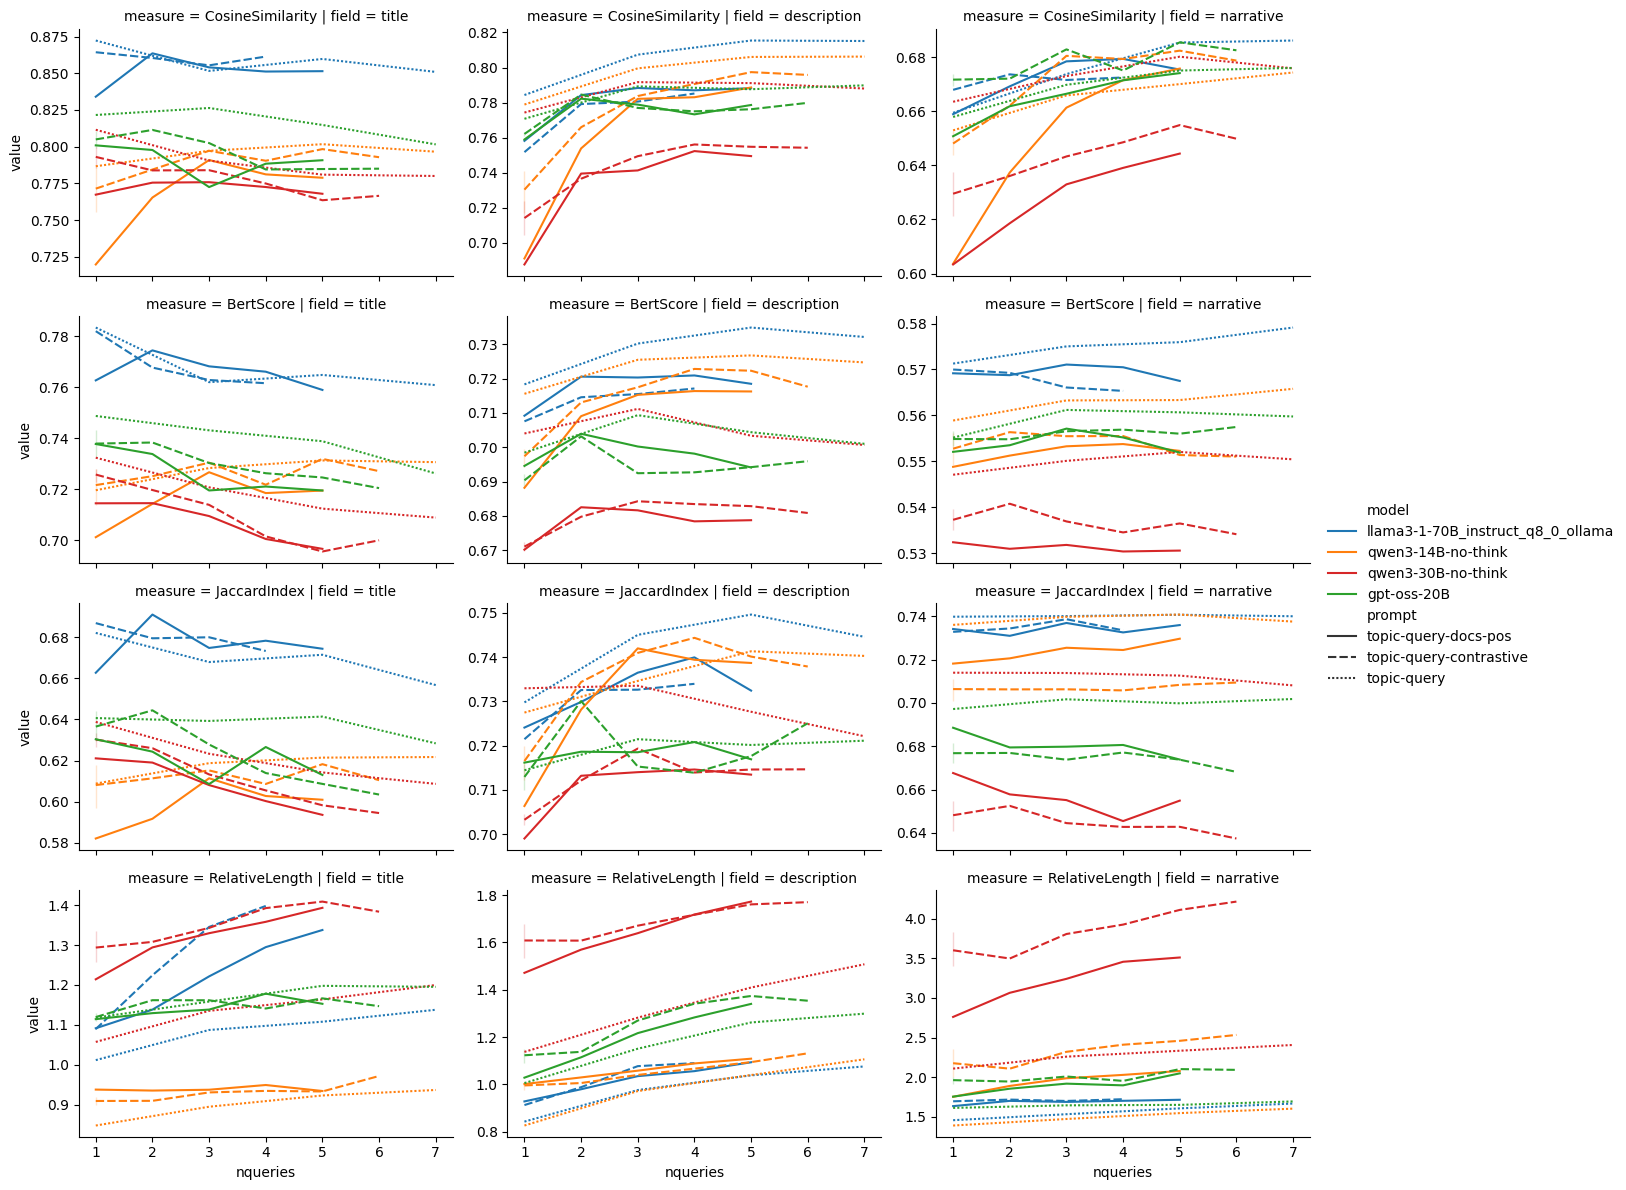

In [61]:
g = sns.relplot(
    data=df[df["prompt"].isin(["topic-query-docs-pos", "topics-query-docs-neg", "topic-query-contrastive", 'topic-query'])],
    x="nqueries",
    y="value",
    hue="model",
    style="prompt",
    row="measure",
    col="field",
    col_order=col_order,
    kind="line",
    height=3,
    palette=model_colors,
    aspect=1.5,
    facet_kws={"sharey": False},
)

# for ax in g.axes.flatten():
#     title = ax.get_title()
#     measure = title.split(" = ")[1].replace(" | field", "")
#     if measure in y_mins:
#         ax.set_ylim(bottom=y_mins[measure])


plt.show()

In [62]:
df.prompt.unique()

array(['topic-query-docs-pos', 'topic-query-contrastive',
       'topic-docs-neg', 'topic-contrastive', 'topic-query',
       'topic-query-docs-neg', 'topic-docs-pos'], dtype=object)

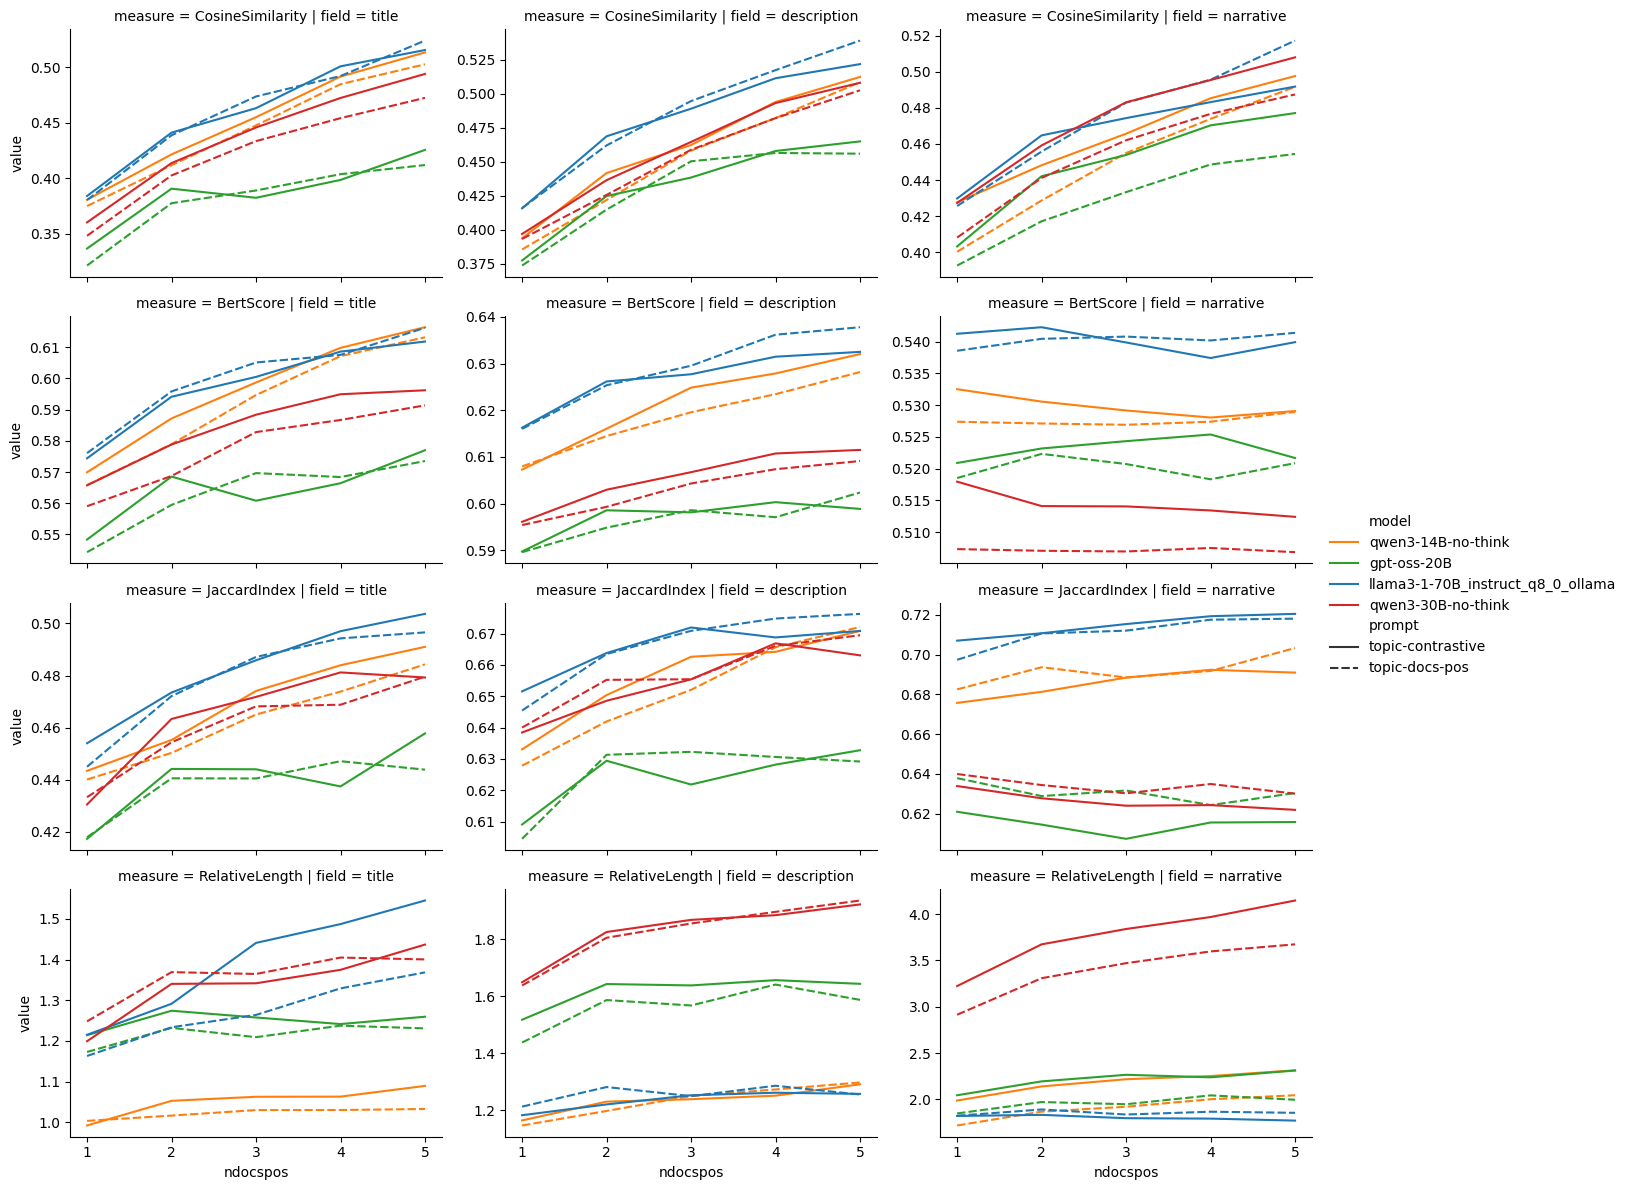

In [63]:
g = sns.relplot(
    data=df[df["prompt"].isin(["topic-contrastive", "topic-docs-pos"])],
    x="ndocspos",
    y="value",
    hue="model",
    style="prompt",
    row="measure",
    col="field",
    col_order=col_order,
    kind="line",
    height=3,
    aspect=1.5,
    palette=model_colors,
    facet_kws={"sharey": False},
)

In [ ]:
# Table
# Context / similarity lineplot
# Nqueries, ndocs vs similarity Heatmap
# examples